## 7. Explicabilidad, preguntas obligatorias y conclusión

In [2]:
# preparación de datos (se elimina al unir con el notebook principal)
import re
import pandas as pd
import numpy as np

def leer_anio(anio):
    d = pd.read_excel(f"data/Precios{anio}.xls", sheet_name="POE (Anual)", skiprows=3, engine="xlrd")
    d.columns = ["fecha", "hora", "precio"]
    d["anio"] = anio
    return d

def a_numero(x):
    if isinstance(x, (int, float)):
        return float(x)
    s = re.sub(r"[^0-9.]", "", str(x))
    if s.count(".") > 1:
        p = s.find(".")
        s = s[:p+1] + s[p+1:].replace(".", "")
    return float(s) if s not in ("", ".") else np.nan

df = pd.concat([leer_anio(a) for a in [2023, 2024, 2025]], ignore_index=True)
df["precio"] = df["precio"].apply(a_numero)
df["hora"] = df["hora"].replace({220: 22, 230: 23, 2300: 23})
df["datetime"] = df["fecha"] + pd.to_timedelta(df["hora"], unit="h")
df = df.sort_values("datetime").reset_index(drop=True)
df["precio"] = df["precio"].interpolate()
df["mes"] = df["datetime"].dt.month
df["dia_sem"] = df["datetime"].dt.dayofweek
df["finde"] = df["dia_sem"] >= 5
train = df[df["anio"] < 2025].copy()

meses_nom = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

### 7.1 ¿Cuál es el comportamiento general del precio de oportunidad de la energía en Guatemala durante 2023 y 2024?

In [3]:
print(train["precio"].describe().round(2))
print("\nMediana por mes:")
print(train.groupby("mes")["precio"].median().round(1).rename(index=lambda m: meses_nom[m-1]))

count      17544.00
mean         284.21
std        12320.15
min            0.63
25%           76.43
50%          101.56
75%          132.10
max      1376899.00
Name: precio, dtype: float64

Mediana por mes:
mes
Ene     78.1
Feb     94.5
Mar    123.0
Abr    125.9
May    160.4
Jun    131.6
Jul    108.0
Ago     95.7
Sep     94.8
Oct     81.5
Nov     80.7
Dic     62.4
Name: precio, dtype: float64


Durante 2023 y 2024 el precio se mantuvo la mayor parte del tiempo alrededor de los 100 USD/MWh. La media es bastante más alta (284) porque la distribución tiene una cola larga hacia la derecha. Existen momentos en que el precio se dispara muy por encima de lo normal, con un máximo que supera el millón. Esos picos son pocos y se concentran sobre todo entre septiembre y octubre de 2023.

A lo largo del año el precio sigue un patrón estacional. Sube entre marzo y junio, siendo mayo el mes más caro, y baja en la segunda mitad del año, con diciembre como el más barato. Esto se relaciona con la dependencia de la generación hidroeléctrica: en época seca el precio es más alto y en época de lluvias baja.

Comparando ambos años, la forma estacional es casi la misma, pero el nivel general cambia un poco de un año al otro.

### 7.2 ¿Qué patrones horarios se observan en el mercado?

In [4]:
por_hora = train.groupby("hora")["precio"].median().round(1)
print(por_hora)
print("\nhora más barata:", por_hora.idxmin(), "| hora más cara:", por_hora.idxmax())

hora
0      79.5
1      77.6
2      76.9
3      76.5
4      77.7
5      81.8
6      89.1
7      97.9
8     104.9
9     108.7
10    110.6
11    113.8
12    115.3
13    115.1
14    115.3
15    117.3
16    117.9
17    117.9
18    124.6
19    126.3
20    122.4
21    115.0
22     91.1
23     81.3
Name: precio, dtype: float64

hora más barata: 3 | hora más cara: 19


Dentro de un mismo día el precio sigue un patrón regular. Como muestra la tabla, es más bajo de madrugada, con el mínimo alrededor de las 3, cuando el consumo es menor. A partir de ahí sube durante el día y llega a su punto más alto en la tarde/noche, con el máximo cerca de las 19. Después vuelve a bajar.

La dispersión también cambia según la hora: en las horas pico la banda entre el P25 y el P75 es más ancha, es decir que en esas horas el precio no solo es más alto sino también más variable.

Este patrón se repite todos los días de la semana, aunque se reduce el contraste el fin de semana.

### 7.3 ¿Existen horas pico, horas intermedias y horas valle? ¿Cómo las definieron?

In [5]:
mh = train.groupby("hora")["precio"].median()
c1, c2 = mh.quantile([1/3, 2/3])
print(f"umbrales (terciles de la mediana):  valle <= {c1:.1f}  <  intermedia <= {c2:.1f}  <  pico")

def clasificar(p):
    if p <= c1: return "valle"
    if p <= c2: return "intermedia"
    return "pico"

grupo = mh.apply(clasificar)
for g in ["valle", "intermedia", "pico"]:
    print(f"{g:11s} ->", sorted(grupo[grupo == g].index.tolist()))

umbrales (terciles de la mediana):  valle <= 90.5  <  intermedia <= 115.2  <  pico
valle       -> [0, 1, 2, 3, 4, 5, 6, 23]
intermedia  -> [7, 8, 9, 10, 11, 13, 21, 22]
pico        -> [12, 14, 15, 16, 17, 18, 19, 20]


Sí. Para definirlas se tomó el precio mediano de cada una de las 24 horas y se separaron en tres grupos según en qué tercio cae ese valor, por debajo de 90.5 USD/MWh son valle, entre 90.5 y 115.2 son intermedias, y por encima de 115.2 son pico.

Con ese criterio las horas valle son de 0 a 6 y la 23, las intermedias son de 7 a 11 más la 13, 21 y 22, y las pico son la 12 y de la 14 a la 20. Se usó la mediana y no la media para que los precios extremos de algunas horas no distorsionaran la clasificación.

### 7.4 ¿El precio parece más influenciado por la hora, el día de la semana o el mes?

In [6]:
rangos = pd.DataFrame(index=["hora", "día de la semana", "mes"])
for nombre, col in zip(rangos.index, ["hora", "dia_sem", "mes"]):
    m = train.groupby(col)["precio"].median()
    rangos.loc[nombre, "min"] = m.min()
    rangos.loc[nombre, "max"] = m.max()
rangos["rango (max-min)"] = rangos["max"] - rangos["min"]
rangos.round(1)

,min,max,rango (max-min)
hora,76.5,126.3,49.9
día de la semana,82.6,109.2,26.6
mes,62.4,160.4,98.1


El mes es el que más influye. Mirando cuánto cambia el precio mediano dentro de cada factor, entre meses va de 62 a 160, entre horas va de 77 a 126, y entre días de la semana va de 83 a 109.

La variación por mes es casi el doble que la de la hora y casi cuatro veces la del día de la semana. Así que el factor estacional pesa más que el momento del día, y el día de la semana es el que menos influye.

### 7.5 ¿Qué tan estable es el comportamiento entre 2023 y 2024?

In [7]:
print(train.groupby("anio")["precio"].agg(["median", "mean", "max"]).round(1))

c23 = train[train["anio"] == 2023].groupby("mes")["precio"].median()
c24 = train[train["anio"] == 2024].groupby("mes")["precio"].median()
print("\ncorrelación de la forma mensual 2023 vs 2024:", round(c23.corr(c24), 2))

      median   mean        max
anio                          
2023   104.9  314.9  1376899.0
2024    96.4  253.6   810402.0

correlación de la forma mensual 2023 vs 2024: 0.6


El comportamiento es parecido pero no igual. Los dos años siguen la patrones similares estacionales, y la forma mensual de ambos está correlacionada de manera positiva. En contraste, la mediana de 2023 fue 104.9 y la de 2024 fue 96.4, por lo que el precio de 2023 estuvo más elevado. Los picos extremos también fueron mayores en 2023, los dos con outliers, pero 2023 con 1.4 millones contra 810 mil en 2024.


### 7.6 ¿Qué eventos o comportamientos atípicos se observan en los datos?

Se observan varios comportamientos atípicos en la serie de precios:

Picos extremos de precio en septiembre y octubre de 2023: se identificaron registros con valores muy por encima del resto de la distribución, (los cuales se pueden observar en la pregunta 7.1)
(la media del precio, ~284 USD/MWh, está muy por encima de la mediana, ~101.56 USD/MWh, y el valor máximo supera el millón de USD/MWh). 



### 7.7 ¿Los valores extremos deben eliminarse, transformarse o conservarse? Justifique.

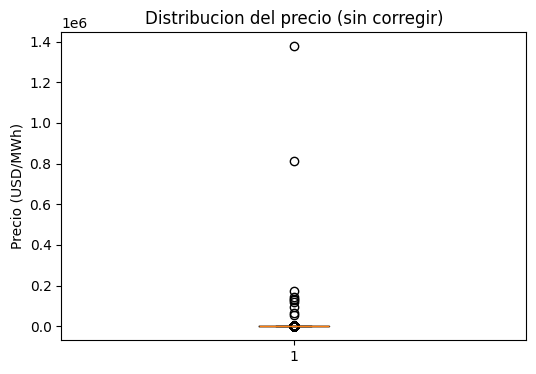

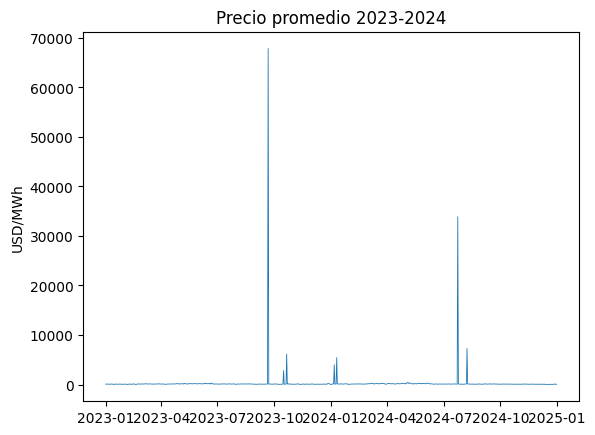

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(df["precio"])
ax.set_title("Distribucion del precio (sin corregir)")
ax.set_ylabel("Precio (USD/MWh)")
plt.show()

diario = train.set_index("datetime")["precio"].resample("D").mean()
plt.plot(diario.index, diario.values, lw=0.6)
plt.title("Precio promedio 2023-2024")
plt.ylabel("USD/MWh")
plt.show()

Los picos encontrados (septiembre-octubre 2023, en el rango de cientos de USD/MWh) deben conservarse, porque reflejan comportamiento real del mercado eléctrico que el modelo necesita aprender a anticipar.

Eliminarlos reduciría la capacidad del modelo de predecir situaciones similares en 2025. 

Se realiza una transformación log del precio para manejar estos picos genuinos, para que la distribución del precio ya no es tan extrema.

### 7.8 ¿Qué variables ayudaron más a reducir el error del modelo?

In [9]:
tabla_coefs = pd.read_csv("tabla_coeficientes.csv")
tabla_coefs

,variable,coeficiente
0,num_escalado__precio_tip_mes_hora,0.152025
1,num_escalado__precio_tip_mes_hora cat_encoded_...,0.068382
2,num_escalado__precio_tip_hora,0.061475
3,remainder__mes_sin remainder__finde,-0.055185
4,cat_encoded__dia_sem_6^2,-0.052270
...,...,...
165,cat_encoded__dia_sem_2 remainder__finde,0.000000
166,cat_encoded__dia_sem_2 cat_encoded__dia_sem_6,0.000000
167,cat_encoded__dia_sem_2 cat_encoded__dia_sem_5,0.000000
168,cat_encoded__grupo_hora_pico cat_encoded__grup...,0.000000


Las variables que más contribuyeron a reducir el error del modelo fueron los promedios históricos de precio (precio_tip_mes_hora y precio_tip_hora, construidos en el inciso 3 a partir de datos de entrenamiento), seguidos por las variables de estacionalidad (mes_cos, estacion). Esto confirma la hipótesis del inciso 3: el comportamiento del precio está fuertemente ligado a patrones recurrentes de mes/hora. 

### 7.9 ¿Qué tan difícil es predecir el precio horario usando únicamente variables derivadas del calendario y patrones históricos?

<div align="center">
    <figure>
        <figcaption><b>Figura 1.</b> Gráfico de dispersión.</figcaption>
        <img src="./graficas/grafico_de_dispersion.png" width="500" alt="Texto alternativo">
        <figcaption><small><i>Fuente: Elaboración propia (2026).</i></small></figcaption>
    </figure>
</div>



Predecir el precio horario de la energía en Guatemala utilizando únicamente variables
derivadas del calendario y patrones históricos presentan un nivel de dificultad elevado
y limitaciones, como se puede apreciar en la **Figura 1**.

Si bien las variables trigonométrcias y estacionales (la hora cíclica o precio típico
por mes) permiten que el modelo aprenda con alta precisión la base del comportamiento
diario, alcanza errores bajos entre los 25 y 49 MWh durante un 95% del tiempo, el modelo
fracasa al intentar predecir los picos extremos del precio, como se evidencia en el
estancamiento del RMSE en valores cercanos a 9,000 MWh.



### 7.10 Si usted fuera parte del Administrador del Mercado Mayorista, ¿confiaría en este modelo para apoyar decisiones sobre el mercado eléctrico?

<div align="center">
    <figure>
        <figcaption><b>Figura 2.</b> Distribución de residuos.</figcaption>
        <img src="./graficas/distribucion_de_residuos.png" width="500" alt="Texto alternativo">
        <figcaption><small><i>Fuente: Elaboración propia (2026).</i></small></figcaption>
    </figure>
</div>



La respuesta es afirmativa: si confiaría en el modelo como una herramienta
de apoyo para la toma de decisiones, viendo como complemento para la gestión 
de riesgos. 

Hay una alta confiabilidad en el regimen operativo común, los diagnósticos estadísticos
(que se observa en la distribución de residuos **Figura 2**) demuestran que en más de 8,000 casos el error se mantiene en un rango predecible, con un MAE de entre 25 y 49 MWh. Para la 
planificación diaria estándar, el modelo provee una línea base estadística que puede
ser de ayuda. 

En el modelo ayudaría al administrador en alertas explícitamente que su debilidad
se concentra en las 17 horas (el dato de MAE es de 154.6 MWH **Figura 3**). Saber cuando el modelo
va a fallar permite al administrador activar protocolos de supervisión humana o integrar
otros modelos analíticos secundarios durante las ventanas de alta volatilidad.

<div align="center">
    <figure>
        <figcaption><b>Figura 3.</b> Error Promedio (MAE) por hora del día.</figcaption>
        <img src="./graficas/error_promedio_hora_del_dia.png" width="700" alt="Texto alternativo">
        <figcaption><small><i>Fuente: Elaboración propia (2026).</i></small></figcaption>
    </figure>
</div>



### 7.11 ¿Qué información adicional podría mejorar el modelo?

En el mercado eléctrico el precio del MWh se fija por el costo de la última planta en entrar a cubrir la demanda. Por
lo tanto, cualquier dato que altere la cantidad de energía disponible o el costo de producirla mejorará considerablemente
el modelo.

- Variables de oferta: podría ser necesario saber cuando una planta generadora sale de operación inesperadamente. Añadir
una columna con lo MW fuera de servicio en tiempo real podría enseñarle al modelo a subir el porcentaje de predicción ante 
la escasez de oferta. 

- Variables hidrológicas y climáticas: Estas resuelven el problema de los puntos que se alejan demasiado en la recta de la
 **Figura 1**. En Guatemala la energía hidroélectrica es un motor importante para la estabilidad. Conocer el nivel de
  almacenamiento de los embalses le permite al modelo entender si hay abundancia de agua, lo que puede llevar a precios bajos
  y estables, o si está racionado el recurso ante una sequía.

  Integrar pronósticos meteorológicos permitirá al modelo anticipar la curva de generación eólica y solar. Intentar predecir picos
  de viento y sol ayudará a predecir con mayor precisión en desplome de precios por exceso de energía limpia.


### Conclusiones

- **Modelo Seleccionadao e Hiperparámetros**  
Se realizó un proceso de experimentación y optimización mediante Validación cruzada de 5 pliegues, el modelo seleccionado como el óptimo para predecir el mercado eléctrico en Guatemala es una combinación de **Polinomial de Grado 2** con **Regularización Ridge**, operando bajo una transformación logarítmica. El proceso de busqueda en malla (GridSearchCV) determinó que el punto de balance en el dilema de sesgo y varianza se alcanza con una penalización de `Alpha = 1000`.

- **Variables relevantes**
El modelo demostró que la complejidad del mercado eléctrico requiere sinergia analítica. Las variables con mayor peso específico y predictivo fueron las interacciones de negocio de segundo grado, tales como el cruce entre los bloques horarios comerciales y las temporadas climáticas, así como la bandera de días no laborales multiplicada por los históricos de referencia. Estas combinaciones permitieron capturar la estructura cíclica de la oferta y la demanda de manera superior a las regresiones lineales tradicionales.

- **Error promedio y comportamiento operativo**
El rendimiento general del modelo estabilizó el Error Absoluto Medio (MAE) promedio de validación cruzada en 236.44 MWh. Haciendo una revisión al horario reveló que el algoritmo predice correctamente en la operación común:
  - Mejores Momentos: Durante la madrugada y horas del Valle (bloques de 0:00 a 5:00h), el modelo es sumamente preciso, manteniendo errores mínimos entre 25 y 31 MWh debido a la estabilidad y predictibilidad de la demanda base.
  - Peores Momentos: El modelo presenta una anomalía predictiva crítica exatamente a las 17h, donde el MAE se dispara de forma aislada hasta los 184.6 MWh, coincidiendo con la carga de la tarde (puesta de sol que probablemente es la disminución de la generación de energía solar y regreso residencial que dispara el consumo).

- **Limitaciones**
La principal limitación del modelo es el sesgo de información. Al utilizar únicamente variables derivadas del calendario y patrones cronológicos históricos, el algoritmo padece de "ceguera" ante eventos imprevistos en tiempo real. Esto explica por qué el error cuadrático (RMSE) se mantuvo estancado en un valor de ~9,000 MWh en todas las arquitecturas de la investigación. El modelo es incapaz de calcular la magnitud exacta de los picos extremos de precio o bien los desplomes repentinos causados por choques físicos del sistema. 

- **Posibles Mejoras**
Para transicionar el modelo a una herramienta de asistencia técnica, con una confianza mayor al 95% para la operación base, hacia un sistema predictivo de alta precisión multivariado, se recomienda incorporar una fase analítica los siguientes datos:
  - Factores de oferta marginal, índices diarios de precios de respaldo (gas natural, diésel) y la tasa de disponibilidad de plantas (MW fuera de servicio por fallas o mantenimientos), que ayudan a definir el precio del MWh.
  - Factores climáticos e hidrológicos, pronósticos de velocidad del viento, radiación solar y niveles de embalses para anticipar la inyección masiva de energía renovable y explicar mejor los desplomes en la red. 